<a href="https://colab.research.google.com/github/iffathsaleem/FYP_Project/blob/main/EDA%20Files/Kbox_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Part 1: Setup

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import gc
import os

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Part 2: Install DuckDB

In [ ]:
!pip -q install duckdb

In [ ]:
import duckdb

con = duckdb.connect()

con.execute("""
SET memory_limit='4GB';
SET threads=2;
SET preserve_insertion_order=false;
""")

print("DuckDB ready.")

DuckDB ready.


## Part 3: Define File Path

In [ ]:
BASE_PATH = Path("/content/drive/MyDrive/FYP/Dataset/kkbox-churn-prediction-challenge")

TRAIN_V2_PATH = BASE_PATH / "train_v2.csv"
TRAIN_PATH = BASE_PATH / "train.csv"
MEMBERS_PATH = BASE_PATH / "members_v3.csv"
TRANSACTIONS_PATH = BASE_PATH / "transactions.csv"
TRANSACTIONS_V2_PATH = BASE_PATH / "transactions_v2.csv"
USER_LOGS_PATH = BASE_PATH / "user_logs.csv"
USER_LOGS_V2_PATH = BASE_PATH / "user_logs_v2.csv"

print(BASE_PATH)

/content/drive/MyDrive/FYP/Dataset/kkbox-churn-prediction-challenge


## Part 4: Check Which Files Exist

In [ ]:
files = {
    "train": TRAIN_PATH,
    "train_v2": TRAIN_V2_PATH,
    "members_v3": MEMBERS_PATH,
    "transactions": TRANSACTIONS_PATH,
    "transactions_v2": TRANSACTIONS_V2_PATH,
    "user_logs": USER_LOGS_PATH,
    "user_logs_v2": USER_LOGS_V2_PATH
}

file_status = []

for name, path in files.items():
    exists = path.exists()
    size_gb = path.stat().st_size / 1024**3 if exists else np.nan
    file_status.append({
        "Dataset": name,
        "Exists": exists,
        "Size_GB": round(size_gb, 3)
    })

file_status_df = pd.DataFrame(file_status)
display(file_status_df)

,Dataset,Exists,Size_GB
0,train,True,0.043
1,train_v2,True,0.043
2,members_v3,True,0.399
3,transactions,True,1.611
4,transactions_v2,True,0.107
5,user_logs,False,NaN
6,user_logs_v2,True,1.333


## Part 5: Preview Schemas Without Loading Large Files

In [ ]:
def preview_csv(path, nrows=5):
    if not path.exists():
        print(f"{path.name} NOT FOUND")
        return

    preview = pd.read_csv(path, nrows=nrows)

    print("\n" + "="*80)
    print(path.name)
    print("="*80)
    print(f"Columns: {len(preview.columns)}")
    print(preview.columns.tolist())
    display(preview)

In [ ]:
preview_csv(TRAIN_V2_PATH)
preview_csv(MEMBERS_PATH)
preview_csv(TRANSACTIONS_V2_PATH)
preview_csv(USER_LOGS_V2_PATH)


train_v2.csv
Columns: 2
['msno', 'is_churn']


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1



members_v3.csv
Columns: 6
['msno', 'city', 'bd', 'gender', 'registered_via', 'registration_init_time']


,msno,city,bd,gender,registered_via,registration_init_time
0,Rb9UwLQTrxzBVwCB6+bCcSQWZ9JiNLC9dXtM1oEsZA8=,1,0,NaN,11,20110911
1,+tJonkh+O1CA796Fm5X60UMOtB6POHAwPjbTRVl/EuU=,1,0,NaN,7,20110914
2,cV358ssn7a0f7jZOwGNWS07wCKVqxyiImJUX6xcIwKw=,1,0,NaN,11,20110915
3,9bzDeJP6sQodK73K5CBlJ6fgIQzPeLnRl0p5B77XP+g=,1,0,NaN,11,20110915
4,WFLY3s7z4EZsieHCt63XrsdtfTEmJ+2PnnKLH5GY4Tk=,6,32,female,9,20110915



transactions_v2.csv
Columns: 9
['msno', 'payment_method_id', 'payment_plan_days', 'plan_list_price', 'actual_amount_paid', 'is_auto_renew', 'transaction_date', 'membership_expire_date', 'is_cancel']


,msno,payment_method_id,payment_plan_days,plan_list_price,actual_amount_paid,is_auto_renew,transaction_date,membership_expire_date,is_cancel
0,++6eU4LsQ3UQ20ILS7d99XK8WbiVgbyYL4FUgzZR134=,32,90,298,298,0,20170131,20170504,0
1,++lvGPJOinuin/8esghpnqdljm6NXS8m8Zwchc7gOeA=,41,30,149,149,1,20150809,20190412,0
2,+/GXNtXWQVfKrEDqYAzcSw2xSPYMKWNj22m+5XkVQZc=,36,30,180,180,1,20170303,20170422,0
3,+/w1UrZwyka4C9oNH3+Q8fUf3fD8R3EwWrx57ODIsqk=,36,30,180,180,1,20170329,20170331,1
4,+00PGzKTYqtnb65mPKPyeHXcZEwqiEzktpQksaaSC3c=,41,30,99,99,1,20170323,20170423,0



user_logs_v2.csv
Columns: 9
['msno', 'date', 'num_25', 'num_50', 'num_75', 'num_985', 'num_100', 'num_unq', 'total_secs']


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,u9E91QDTvHLq6NXjEaWv8u4QIqhrHk72kE+w31Gnhdg=,20170331,8,4,0,1,21,18,6309.273
1,nTeWW/eOZA/UHKdD5L7DEqKKFTjaAj3ALLPoAWsU8n0=,20170330,2,2,1,0,9,11,2390.699
2,2UqkWXwZbIjs03dHLU9KHJNNEvEkZVzm69f3jCS+uLI=,20170331,52,3,5,3,84,110,23203.337
3,ycwLc+m2O0a85jSLALtr941AaZt9ai8Qwlg9n0Nql5U=,20170331,176,4,2,2,19,191,7100.454
4,EGcbTofOSOkMmQyN1NMLxHEXJ1yV3t/JdhGwQ9wXjnI=,20170331,2,1,0,1,112,93,28401.558


## Part 6: Load Churn Labels

In [ ]:
train = pd.read_csv(TRAIN_V2_PATH, dtype={"msno": "string", "is_churn": "uint8"})

print("Train shape:", train.shape)
display(train.head())

Train shape: (970960, 2)


,msno,is_churn
0,ugx0CjOMzazClkFzU2xasmDZaoIqOUAZPsH1q0teWCg=,1
1,f/NmvEzHfhINFEYZTR05prUdr+E+3+oewvweYz9cCQE=,1
2,zLo9f73nGGT1p21ltZC3ChiRnAVvgibMyazbCxvWPcg=,1
3,8iF/+8HY8lJKFrTc7iR9ZYGCG2Ecrogbc2Vy5YhsfhQ=,1
4,K6fja4+jmoZ5xG6BypqX80Uw/XKpMgrEMdG2edFOxnA=,1


## Part 7: Churn Target Analysis

In [ ]:
print("\n" + "="*80)
print("PART 1: CHURN TARGET ANALYSIS")
print("="*80)

churn_summary = train["is_churn"].value_counts().rename_axis("is_churn").reset_index(name="Customers")
churn_summary["Percentage"] = churn_summary["Customers"] / len(train) * 100

display(churn_summary)


PART 1: CHURN TARGET ANALYSIS


,is_churn,Customers,Percentage
0,0,883630,91.005809
1,1,87330,8.994191


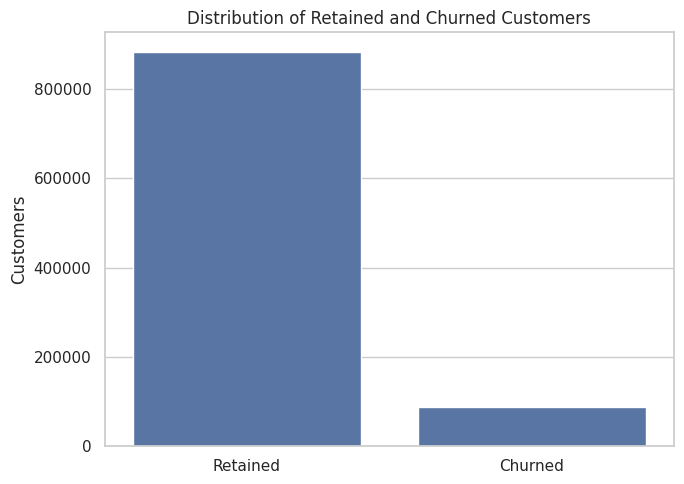

In [ ]:
plt.figure(figsize=(7,5))
ax = sns.countplot(data=train, x="is_churn")
plt.xticks([0,1], ["Retained", "Churned"])
plt.xlabel("")
plt.ylabel("Customers")
plt.title("Distribution of Retained and Churned Customers")
plt.tight_layout()
plt.show()

## Part 8: Churn Imbalance Ratio

In [ ]:
retained = (train["is_churn"] == 0).sum()
churned = (train["is_churn"] == 1).sum()

print(f"Retained customers: {retained:,}")
print(f"Churned customers: {churned:,}")
print(f"Retained : Churn ratio = {retained/churned:.2f}:1")

Retained customers: 883,630
Churned customers: 87,330
Retained : Churn ratio = 10.12:1


## Part 9: Churn Definition Context

In [ ]:
print("""
KKBOX churn interpretation used in this study:

is_churn = 0:
    User renewed within the permitted renewal window.

is_churn = 1:
    User did not renew or renewal occurred after the churn threshold.

The supplied WSDM churn labelling logic uses a 30-day renewal-gap threshold.

For this FYP, churn is NOT treated as a BNPL repayment default.
It is used as a temporal behavioural proxy for studying how user
behaviour changes before an adverse outcome.
""")


KKBOX churn interpretation used in this study:

is_churn = 0:
    User renewed within the permitted renewal window.

is_churn = 1:
    User did not renew or renewal occurred after the churn threshold.

The supplied WSDM churn labelling logic uses a 30-day renewal-gap threshold.

For this FYP, churn is NOT treated as a BNPL repayment default.
It is used as a temporal behavioural proxy for studying how user
behaviour changes before an adverse outcome.



## Part 10: Compare Train vs Train_v2

In [ ]:
if TRAIN_PATH.exists():
    train_old = pd.read_csv(TRAIN_PATH, dtype={"msno": "string", "is_churn": "uint8"})
    print("Previous-period train:", train_old.shape)
    print("Current train_v2:", train.shape)

Previous-period train: (992931, 2)
Current train_v2: (970960, 2)


In [ ]:
if TRAIN_PATH.exists():
    label_transition = train_old.rename(columns={"is_churn": "PREVIOUS_CHURN"}).merge(
        train.rename(columns={"is_churn": "CURRENT_CHURN"}), on="msno", how="inner"
    )
    print("Users appearing in both periods:", f"{len(label_transition):,}")

Users appearing in both periods: 881,701


### 10.1 Churn Transition Matrix

In [ ]:
if TRAIN_PATH.exists():
    transition_table = pd.crosstab(
        label_transition["PREVIOUS_CHURN"],
        label_transition["CURRENT_CHURN"],
        normalize="index"
    ) * 100
    display(transition_table)

CURRENT_CHURN,0,1
PREVIOUS_CHURN,,
0,95.294437,4.705563
1,32.283561,67.716439


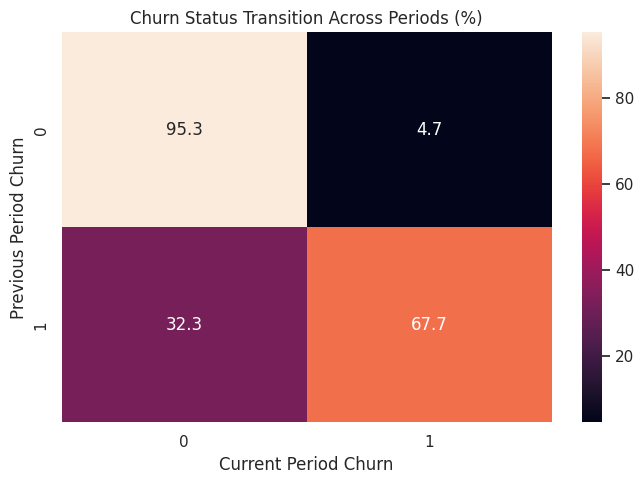

In [ ]:
if TRAIN_PATH.exists():
    plt.figure(figsize=(7,5))
    sns.heatmap(transition_table, annot=True, fmt=".1f")
    plt.xlabel("Current Period Churn")
    plt.ylabel("Previous Period Churn")
    plt.title("Churn Status Transition Across Periods (%)")
    plt.tight_layout()
    plt.show()

## Part 11: Member Profile EDA

In [ ]:
con.register("train_labels", train)

members = con.execute(
    f"""
    SELECT
        m.*
    FROM read_csv_auto(
        '{MEMBERS_PATH}',
        header=true
    ) m
    INNER JOIN train_labels t
        ON m.msno = t.msno
    """
).df()

print("Matched member records:", members.shape)
display(members.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Matched member records: (860967, 6)


,msno,city,bd,gender,registered_via,registration_init_time
0,9YU38aJ1zAV5iLD08+Vj/HgWxHsQO8dR2ZesnaWUlVw=,4,47,male,9,20050312
1,OwWLj62gLRGDDGyO47MaQOhR1/XRqgWvodUZsE4rEGI=,18,31,male,9,20050320
2,UwggUNf4aLDm6AiF/s2JiJUMjpvSIpRvR/NocLQBBi0=,4,45,female,9,20050323
3,NSHTUkXtKSN0/nfccl781QnuCrSMZOIBCVzTalCrgVY=,15,33,male,9,20050324
4,kyNMuomAmkdUX2p0n0tQpbghoQ31ZpfTsembe+U0SNU=,13,25,male,9,20050330


In [ ]:
members = members.merge(train, on="msno", how="left")

## Part 12: Member Data Quality

In [ ]:
print("\n" + "="*80)
print("PART 2: MEMBER DATA QUALITY")
print("="*80)

member_missing = pd.DataFrame({
    "Missing_Count": members.isna().sum(),
    "Missing_Percentage": members.isna().mean() * 100,
    "Unique_Values": [members[c].nunique(dropna=False) for c in members.columns]
})

display(member_missing.sort_values("Missing_Percentage", ascending=False))


PART 2: MEMBER DATA QUALITY


,Missing_Count,Missing_Percentage,Unique_Values
gender,472062,54.829279,3
city,0,0.000000,21
msno,0,0.000000,860967
bd,0,0.000000,231
registered_via,0,0.000000,5
registration_init_time,0,0.000000,4749
is_churn,0,0.000000,2


## Part 13: Age Analysis

In [ ]:
display(members["bd"].describe(percentiles=[.01, .05, .25, .50, .75, .95, .99]))

,bd
count,860967.000000
mean,13.583854
std,20.064040
min,-3152.000000
1%,0.000000
5%,0.000000
25%,0.000000
50%,0.000000
75%,27.000000
95%,41.000000


In [ ]:
print("Age <= 0:", (members["bd"] <= 0).sum())
print("Age > 100:", (members["bd"] > 100).sum())

Age <= 0: 473798
Age > 100: 454


In [ ]:
members["AGE_CLEAN"] = members["bd"].where(members["bd"].between(10,100))

## Part 14: Age Distribution by Churn

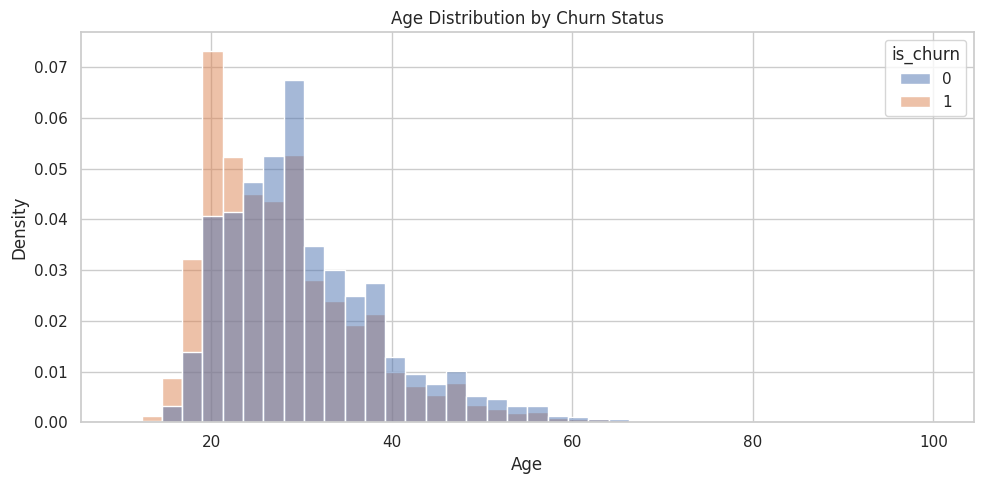

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(data=members[members["AGE_CLEAN"].notna()], x="AGE_CLEAN", hue="is_churn",
             bins=40, stat="density", common_norm=False)
plt.title("Age Distribution by Churn Status")
plt.xlabel("Age")
plt.tight_layout()
plt.show()

## Part 15: Age Groups and Churn Rate

In [ ]:
members["AGE_GROUP"] = pd.cut(members["AGE_CLEAN"], bins=[10,20,30,40,50,60,70,100])

In [ ]:
age_churn = members.groupby("AGE_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
age_churn["Churn_Rate"] *= 100
display(age_churn)

,Customers,Churn_Rate
AGE_GROUP,,
"(10, 20]",41428,24.522062
"(20, 30]",195420,13.040119
"(30, 40]",104707,10.772919
"(40, 50]",32315,10.184125
"(50, 60]",10429,8.217471
"(60, 70]",1822,10.373216
"(70, 100]",480,10.416667


## Part 16: Gender EDA

In [ ]:
gender_churn = members.groupby("gender", dropna=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
gender_churn["Churn_Rate"] *= 100
display(gender_churn)

,Customers,Churn_Rate
gender,,
female,184344,12.98659
male,204561,12.90373
NaN,472062,6.59066


## Part 17: City EDA

In [ ]:
city_churn = members.groupby("city", dropna=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
city_churn["Churn_Rate"] *= 100
city_churn = city_churn[city_churn["Customers"] >= 100].sort_values("Churn_Rate", ascending=False)
display(city_churn.head(20))

,Customers,Churn_Rate
city,,
21,5199,14.714368
12,11383,13.924273
8,7589,13.453683
3,5057,13.288511
10,6470,13.261206
5,70706,13.199728
4,47227,12.903636
6,26066,12.882682
15,43187,12.823303


## Part 18: Registration Channel

In [ ]:
registered_via_churn = members.groupby("registered_via", dropna=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
registered_via_churn["Churn_Rate"] *= 100
display(registered_via_churn)

,Customers,Churn_Rate
registered_via,,
3,106459,17.225411
4,52744,23.102154
7,462684,4.473247
9,235689,12.683239
13,3391,9.879092


## Part 19: Registration Date

In [ ]:
members["REGISTRATION_DATE"] = pd.to_datetime(
    members["registration_init_time"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce"
)
members["REGISTRATION_YEAR"] = members["REGISTRATION_DATE"].dt.year

In [ ]:
registration_churn = members.groupby("REGISTRATION_YEAR")["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
registration_churn["Churn_Rate"] *= 100
display(registration_churn)

,Customers,Churn_Rate
REGISTRATION_YEAR,,
2004,8330,8.787515
2005,15616,6.807121
2006,18048,8.139406
2007,26158,9.045034
2008,17685,10.042409
2009,15731,11.086390
2010,38640,11.638199
2011,60698,8.784474
2012,74495,9.622122


## Part 20: Transaction EDA

In [ ]:
tx_files = []
if TRANSACTIONS_PATH.exists():
    tx_files.append(str(TRANSACTIONS_PATH))
if TRANSACTIONS_V2_PATH.exists():
    tx_files.append(str(TRANSACTIONS_V2_PATH))

print(tx_files)

['/content/drive/MyDrive/FYP/Dataset/kkbox-churn-prediction-challenge/transactions.csv', '/content/drive/MyDrive/FYP/Dataset/kkbox-churn-prediction-challenge/transactions_v2.csv']


In [ ]:
tx_sql_files = ",".join([f"'{p}'" for p in tx_files])
TX_SOURCE = f"""
read_csv_auto(
    [{tx_sql_files}],
    header=true,
    union_by_name=true
)
"""

### 20.1 Transaction-Level Dataset Overview

In [ ]:
transaction_overview = con.execute(
    f"""
    SELECT
        COUNT(*) AS transaction_rows,
        COUNT(DISTINCT msno) AS unique_users,
        MIN(transaction_date) AS first_transaction,
        MAX(transaction_date) AS last_transaction,
        AVG(actual_amount_paid) AS avg_amount_paid,
        AVG(payment_plan_days) AS avg_plan_days,
        AVG(is_auto_renew) AS auto_renew_rate,
        AVG(is_cancel) AS cancellation_rate
    FROM {TX_SOURCE}
    """
).df()

display(transaction_overview)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,transaction_rows,unique_users,first_transaction,last_transaction,avg_amount_paid,avg_plan_days,auto_renew_rate,cancellation_rate
0,22978755,2426143,20150101,20170331,150.664134,33.498685,0.847815,0.038818


### 20.2 Transaction Data Matched to Study Users

In [ ]:
tx_coverage = con.execute(
    f"""
    SELECT
        COUNT(DISTINCT x.msno)
            AS users_with_transaction_history
    FROM {TX_SOURCE} x
    INNER JOIN train_labels t
        ON x.msno = t.msno
    """
).df()

display(tx_coverage)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,users_with_transaction_history
0,970960


### 20.3 Aggregate Transaction Behaviour Per Customer

In [ ]:
transaction_features = con.execute(
    f"""
    SELECT
        x.msno,
        COUNT(*) AS TRANSACTION_COUNT,
        COUNT(DISTINCT substr(CAST(transaction_date AS VARCHAR), 1, 6)) AS ACTIVE_TRANSACTION_MONTHS,
        AVG(payment_plan_days) AS AVG_PLAN_DAYS,
        AVG(plan_list_price) AS AVG_LIST_PRICE,
        AVG(actual_amount_paid) AS AVG_AMOUNT_PAID,
        SUM(actual_amount_paid) AS TOTAL_AMOUNT_PAID,
        AVG(plan_list_price - actual_amount_paid) AS AVG_DISCOUNT,
        AVG(CASE WHEN actual_amount_paid < plan_list_price THEN 1 ELSE 0 END) AS DISCOUNT_RATE,
        AVG(is_auto_renew) AS AUTO_RENEW_RATE,
        AVG(is_cancel) AS CANCELLATION_RATE,
        MIN(transaction_date) AS FIRST_TRANSACTION,
        MAX(transaction_date) AS LAST_TRANSACTION,
        MAX(membership_expire_date) AS LAST_MEMBERSHIP_EXPIRY,
        arg_max(payment_plan_days, transaction_date) AS LATEST_PLAN_DAYS,
        arg_max(actual_amount_paid, transaction_date) AS LATEST_AMOUNT_PAID,
        arg_max(is_auto_renew, transaction_date) AS LATEST_AUTO_RENEW,
        arg_max(is_cancel, transaction_date) AS LATEST_CANCEL,
        arg_min(is_auto_renew, transaction_date) AS FIRST_AUTO_RENEW,
        arg_min(is_cancel, transaction_date) AS FIRST_CANCEL
    FROM {TX_SOURCE} x
    INNER JOIN train_labels t
        ON x.msno = t.msno
    GROUP BY x.msno
    """
).df()

print(transaction_features.shape)
display(transaction_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(970960, 20)


,msno,TRANSACTION_COUNT,ACTIVE_TRANSACTION_MONTHS,AVG_PLAN_DAYS,AVG_LIST_PRICE,AVG_AMOUNT_PAID,TOTAL_AMOUNT_PAID,AVG_DISCOUNT,DISCOUNT_RATE,AUTO_RENEW_RATE,CANCELLATION_RATE,FIRST_TRANSACTION,LAST_TRANSACTION,LAST_MEMBERSHIP_EXPIRY,LATEST_PLAN_DAYS,LATEST_AMOUNT_PAID,LATEST_AUTO_RENEW,LATEST_CANCEL,FIRST_AUTO_RENEW,FIRST_CANCEL
0,otEcMhAX3mU4gumUSogqgteN3oaNmhdmTkoof2iRYEE=,25,24,28.800000,143.040000,149.000000,3725.0,-5.96,0.0,0.2,0.000000,20150113,20170326,20170525,30,149,1,0,0,0
1,jusBdRLC+UmeEWMO/aDjwWPjWrvSR/luJtSvFoaeFxs=,13,13,30.000000,99.000000,99.000000,1287.0,0.00,0.0,1.0,0.076923,20160328,20170327,20170327,30,99,1,1,1,0
2,ERRkkEYVoS0Cq6zXuMJlkqWwOgTfAEHHNuS78ENE0dA=,4,3,71.250000,343.000000,343.000000,1372.0,0.00,0.0,0.5,0.250000,20170114,20170314,20170928,195,894,0,0,0,0
3,gQQ1alAkK9IsVAq/yHeD9aQPRxwtqoDWMAKG+EqUSKM=,28,27,30.000000,145.428571,145.428571,4072.0,0.00,0.0,1.0,0.035714,20150120,20170301,20170706,30,99,1,0,1,0
4,GZQcC7miYH/JgA31huWbW0giztURG755hRH6yA9QbNU=,30,27,30.133333,145.000000,145.000000,4350.0,0.00,0.0,1.0,0.066667,20150119,20170324,20170423,30,149,1,1,1,0


## Part 21: Transaction Behaviour Change Features

In [ ]:
transaction_features["AUTO_RENEW_CHANGE"] = transaction_features["LATEST_AUTO_RENEW"] - transaction_features["FIRST_AUTO_RENEW"]
transaction_features["CANCEL_CHANGE"] = transaction_features["LATEST_CANCEL"] - transaction_features["FIRST_CANCEL"]

## Part 22: Parse Transaction Dates

In [ ]:
date_cols = ["FIRST_TRANSACTION", "LAST_TRANSACTION", "LAST_MEMBERSHIP_EXPIRY"]

for col in date_cols:
    transaction_features[col + "_DATE"] = pd.to_datetime(
        transaction_features[col].astype("Int64").astype(str),
        format="%Y%m%d",
        errors="coerce"
    )

## Part 23: Customer Relationship Duration

In [ ]:
transaction_features["TRANSACTION_HISTORY_DAYS"] = (
    transaction_features["LAST_TRANSACTION_DATE"] - transaction_features["FIRST_TRANSACTION_DATE"]
).dt.days

## Part 24: Transaction Recency

In [ ]:
REFERENCE_DATE = transaction_features["LAST_TRANSACTION_DATE"].max()
print("Reference date:", REFERENCE_DATE)

Reference date: 2017-03-31 00:00:00


In [ ]:
transaction_features["TRANSACTION_RECENCY_DAYS"] = (
    REFERENCE_DATE - transaction_features["LAST_TRANSACTION_DATE"]
).dt.days

## Part 25: RFM-Style Variables

In [ ]:
transaction_features["R_RECENCY"] = transaction_features["TRANSACTION_RECENCY_DAYS"]
transaction_features["F_FREQUENCY"] = transaction_features["TRANSACTION_COUNT"]
transaction_features["M_MONETARY"] = transaction_features["TOTAL_AMOUNT_PAID"]

## Part 26: Merge Transaction Features with Churn

In [ ]:
customer_tx = train.merge(transaction_features, on="msno", how="left")
print(customer_tx.shape)

(970960, 31)


## Part 27: Missing Transaction History

In [ ]:
customer_tx["HAS_TRANSACTION_HISTORY"] = customer_tx["TRANSACTION_COUNT"].notna().astype("uint8")

In [ ]:
history_churn = customer_tx.groupby("HAS_TRANSACTION_HISTORY")["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
history_churn["Churn_Rate"] *= 100
display(history_churn)

,Customers,Churn_Rate
HAS_TRANSACTION_HISTORY,,
1,970960,8.994191


## Part 28: Auto-Renew vs Churn

In [ ]:
display(customer_tx.groupby("is_churn")[["AUTO_RENEW_RATE", "LATEST_AUTO_RENEW"]].mean().T)

is_churn,0,1
AUTO_RENEW_RATE,0.910535,0.476646
LATEST_AUTO_RENEW,0.926211,0.444143


In [ ]:
auto_renew_churn = customer_tx.groupby("LATEST_AUTO_RENEW")["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
auto_renew_churn["Churn_Rate"] *= 100
display(auto_renew_churn)

,Customers,Churn_Rate
LATEST_AUTO_RENEW,,
0,113745,42.677041
1,857215,4.524769


## Part 29: Cancellation Behaviour vs Churn

In [ ]:
cancel_churn = customer_tx.groupby("LATEST_CANCEL")["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
cancel_churn["Churn_Rate"] *= 100
display(cancel_churn)

,Customers,Churn_Rate
LATEST_CANCEL,,
0,940442,6.564466
1,30518,83.868537


In [ ]:
display(customer_tx.groupby("is_churn")["CANCELLATION_RATE"].describe())

,count,mean,std,min,25%,50%,75%,max
is_churn,,,,,,,,
0,883630.0,0.013215,0.032571,0.0,0.0,0.0,0.000000,0.666667
1,87330.0,0.043241,0.080555,0.0,0.0,0.0,0.066667,1.000000


## Part 30: Churn by Transaction Frequency

In [ ]:
customer_tx["TRANSACTION_FREQ_GROUP"] = pd.qcut(customer_tx["TRANSACTION_COUNT"], q=5, duplicates="drop")

In [ ]:
frequency_churn = customer_tx.groupby("TRANSACTION_FREQ_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
frequency_churn["Churn_Rate"] *= 100
display(frequency_churn)

,Customers,Churn_Rate
TRANSACTION_FREQ_GROUP,,
"(0.999, 8.0]",213789,18.365304
"(8.0, 14.0]",180045,8.200728
"(14.0, 20.0]",193325,5.720936
"(20.0, 27.0]",291795,5.379804
"(27.0, 244.0]",92006,7.112580


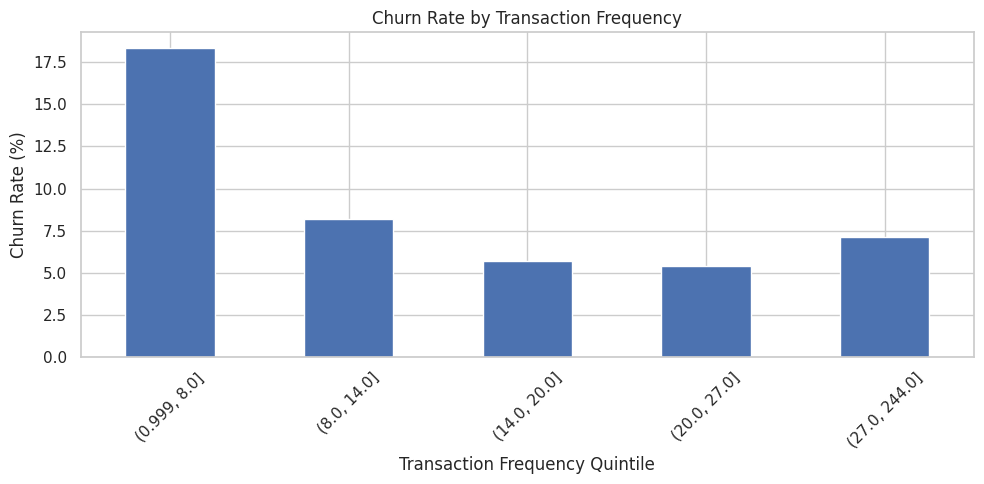

In [ ]:
frequency_churn["Churn_Rate"].plot(kind="bar", figsize=(10,5))
plt.title("Churn Rate by Transaction Frequency")
plt.ylabel("Churn Rate (%)")
plt.xlabel("Transaction Frequency Quintile")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Part 31: Churn by Transaction Recency

In [ ]:
customer_tx["RECENCY_GROUP"] = pd.qcut(customer_tx["TRANSACTION_RECENCY_DAYS"], q=5, duplicates="drop")

In [ ]:
recency_churn = customer_tx.groupby("RECENCY_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
recency_churn["Churn_Rate"] *= 100
display(recency_churn)

,Customers,Churn_Rate
RECENCY_GROUP,,
"(-0.001, 3.0]",200384,3.605577
"(3.0, 10.0]",193088,5.387181
"(10.0, 17.0]",198965,5.652250
"(17.0, 25.0]",210532,6.718219
"(25.0, 819.0]",167991,26.378199


## Part 32: Churn by Monetary Value

In [ ]:
customer_tx["MONETARY_GROUP"] = pd.qcut(customer_tx["TOTAL_AMOUNT_PAID"], q=5, duplicates="drop")

In [ ]:
monetary_churn = customer_tx.groupby("MONETARY_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
monetary_churn["Churn_Rate"] *= 100
display(monetary_churn)

,Customers,Churn_Rate
MONETARY_GROUP,,
"(-0.001, 990.0]",211669,9.337692
"(990.0, 1683.0]",183529,8.303320
"(1683.0, 2980.0]",191902,11.000928
"(2980.0, 3701.0]",189765,8.165362
"(3701.0, 16800.0]",194095,8.099127


## Part 33: Subscription Behaviour by Churn

In [ ]:
behaviour_features = [
    "TRANSACTION_COUNT",
    "ACTIVE_TRANSACTION_MONTHS",
    "AVG_PLAN_DAYS",
    "AVG_AMOUNT_PAID",
    "TOTAL_AMOUNT_PAID",
    "AVG_DISCOUNT",
    "DISCOUNT_RATE",
    "AUTO_RENEW_RATE",
    "CANCELLATION_RATE",
    "TRANSACTION_RECENCY_DAYS"
]

In [ ]:
behaviour_summary = customer_tx.groupby("is_churn")[behaviour_features].median().T
behaviour_summary.columns = ["Retained_Median", "Churned_Median"]
display(behaviour_summary)

,Retained_Median,Churned_Median
TRANSACTION_COUNT,18.000000,10.000000
ACTIVE_TRANSACTION_MONTHS,17.000000,10.000000
AVG_PLAN_DAYS,30.000000,30.000000
AVG_AMOUNT_PAID,138.655172,149.000000
TOTAL_AMOUNT_PAID,2035.000000,2086.000000
AVG_DISCOUNT,0.000000,0.000000
DISCOUNT_RATE,0.000000,0.000000
AUTO_RENEW_RATE,1.000000,0.333333
CANCELLATION_RATE,0.000000,0.000000
TRANSACTION_RECENCY_DAYS,13.000000,26.000000


## Part 34: Multi-Time-Point Transaction EDA

In [ ]:
monthly_transactions = con.execute(
    f"""
    SELECT
        x.msno,
        substr(CAST(transaction_date AS VARCHAR), 1, 6) AS MONTH,
        COUNT(*) AS TRANSACTION_COUNT,
        AVG(actual_amount_paid) AS AVG_AMOUNT_PAID,
        SUM(actual_amount_paid) AS TOTAL_AMOUNT_PAID,
        AVG(payment_plan_days) AS AVG_PLAN_DAYS,
        AVG(is_auto_renew) AS AUTO_RENEW_RATE,
        AVG(is_cancel) AS CANCELLATION_RATE
    FROM {TX_SOURCE} x
    INNER JOIN train_labels t
        ON x.msno = t.msno
    GROUP BY x.msno, MONTH
    """
).df()

print(monthly_transactions.shape)
display(monthly_transactions.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(15713794, 8)


,msno,MONTH,TRANSACTION_COUNT,AVG_AMOUNT_PAID,TOTAL_AMOUNT_PAID,AVG_PLAN_DAYS,AUTO_RENEW_RATE,CANCELLATION_RATE
0,YOF2Z5cnRQQzJ0+jO1k+0nkQ5rO2KDZA1x+XbZ2vPaw=,201604,1,99.0,99.0,30.0,1.0,0.0
1,z31E7fn8r0Xz3mclyGHI6SkZCdJJ2wPMLxz6kiVrFg0=,201703,1,149.0,149.0,30.0,0.0,0.0
2,gE7gAVLO8Ul8XsHpMZ3fPWgwGfuwRLyyeH6P1VOFoEk=,201701,1,149.0,149.0,30.0,0.0,0.0
3,SLr0aCGKcGfbQ/XLRi9QrU4955qRh6LcaPnABDE6Uf8=,201703,2,129.0,258.0,30.0,1.0,0.5
4,JuFyCkq/EoAzZLb2UQEwNWCeRZh6rVg+HN3GeOrE51Y=,201703,1,149.0,149.0,30.0,1.0,1.0


## Part 35: Number of Observed Months Per Customer

In [ ]:
months_observed = monthly_transactions.groupby("msno")["MONTH"].nunique().rename("MONTHS_OBSERVED")

In [ ]:
display(months_observed.describe(percentiles=[.25,.50,.75,.90,.95,.99]))

,MONTHS_OBSERVED
count,970960.000000
mean,16.183771
std,8.260580
min,1.000000
25%,9.000000
50%,17.000000
75%,23.000000
90%,27.000000
95%,27.000000
99%,27.000000


## Part 36: First vs Latest Behaviour

In [ ]:
monthly_transactions = monthly_transactions.sort_values(["msno", "MONTH"])

In [ ]:
first_month = monthly_transactions.groupby("msno", as_index=False).first()

In [ ]:
last_month = monthly_transactions.groupby("msno", as_index=False).last()

In [ ]:
first_month = first_month.rename(columns={
    "TRANSACTION_COUNT": "FIRST_TX_COUNT",
    "AVG_AMOUNT_PAID": "FIRST_AVG_PAID",
    "AUTO_RENEW_RATE": "FIRST_AUTO_RENEW_RATE",
    "CANCELLATION_RATE": "FIRST_CANCEL_RATE"
})

In [ ]:
last_month = last_month.rename(columns={
    "TRANSACTION_COUNT": "LATEST_TX_COUNT",
    "AVG_AMOUNT_PAID": "LATEST_AVG_PAID",
    "AUTO_RENEW_RATE": "LATEST_AUTO_RENEW_RATE",
    "CANCELLATION_RATE": "LATEST_CANCEL_RATE"
})

## Part 37: Behaviour Change Variables

In [ ]:
trajectory = first_month[["msno", "FIRST_TX_COUNT", "FIRST_AVG_PAID", "FIRST_AUTO_RENEW_RATE", "FIRST_CANCEL_RATE"]].merge(
    last_month[["msno", "LATEST_TX_COUNT", "LATEST_AVG_PAID", "LATEST_AUTO_RENEW_RATE", "LATEST_CANCEL_RATE"]],
    on="msno",
    how="inner"
)

In [ ]:
trajectory["TX_COUNT_CHANGE"] = trajectory["LATEST_TX_COUNT"] - trajectory["FIRST_TX_COUNT"]
trajectory["PAID_AMOUNT_CHANGE"] = trajectory["LATEST_AVG_PAID"] - trajectory["FIRST_AVG_PAID"]
trajectory["AUTO_RENEW_CHANGE"] = trajectory["LATEST_AUTO_RENEW_RATE"] - trajectory["FIRST_AUTO_RENEW_RATE"]
trajectory["CANCEL_RATE_CHANGE"] = trajectory["LATEST_CANCEL_RATE"] - trajectory["FIRST_CANCEL_RATE"]

## Part 38: Merge Trajectory with Churn

In [ ]:
trajectory = trajectory.merge(train, on="msno", how="left")

## Part 39: Trajectory Summary by Churn

In [ ]:
trajectory_features = ["TX_COUNT_CHANGE", "PAID_AMOUNT_CHANGE", "AUTO_RENEW_CHANGE", "CANCEL_RATE_CHANGE"]

In [ ]:
trajectory_summary = trajectory.groupby("is_churn")[trajectory_features].median().T
trajectory_summary.columns = ["Retained_Median", "Churned_Median"]
display(trajectory_summary)

,Retained_Median,Churned_Median
TX_COUNT_CHANGE,0.0,0.0
PAID_AMOUNT_CHANGE,0.0,0.0
AUTO_RENEW_CHANGE,0.0,0.0
CANCEL_RATE_CHANGE,0.0,0.0


## Part 40: Cancellation Deterioration

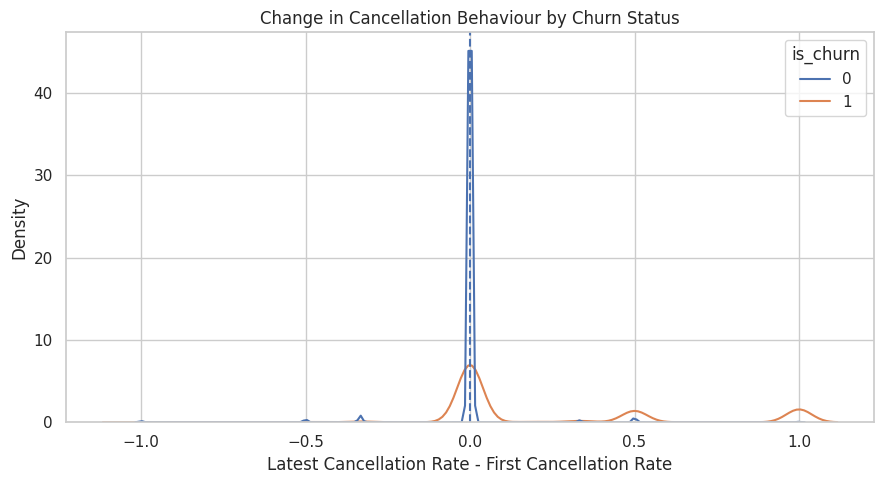

In [ ]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=trajectory, x="CANCEL_RATE_CHANGE", hue="is_churn", common_norm=False)
plt.axvline(0, linestyle="--")
plt.title("Change in Cancellation Behaviour by Churn Status")
plt.xlabel("Latest Cancellation Rate - First Cancellation Rate")
plt.tight_layout()
plt.show()

## Part 41: Auto-Renew Trajectory

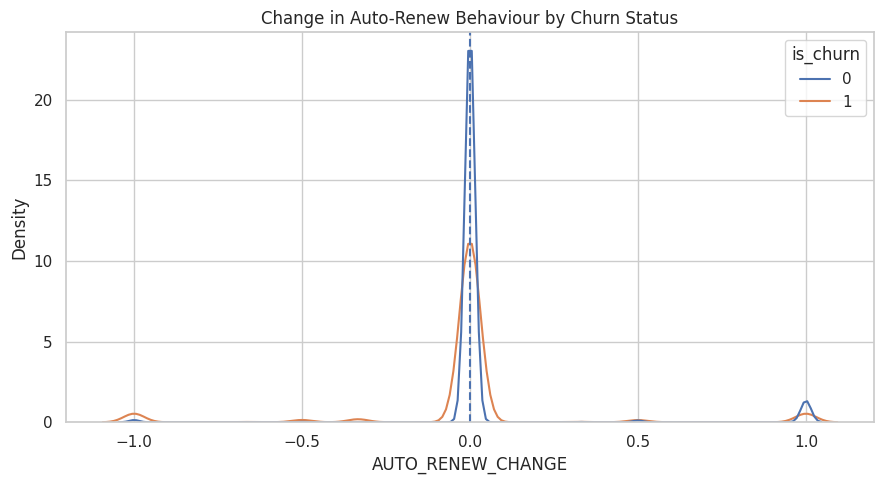

In [ ]:
plt.figure(figsize=(9,5))
sns.kdeplot(data=trajectory, x="AUTO_RENEW_CHANGE", hue="is_churn", common_norm=False)
plt.axvline(0, linestyle="--")
plt.title("Change in Auto-Renew Behaviour by Churn Status")
plt.tight_layout()
plt.show()

## Part 42: User Log EDA

In [ ]:
LOG_SOURCE = f"""
read_csv_auto(
    '{USER_LOGS_V2_PATH}',
    header=true
)
"""

In [ ]:
log_overview = con.execute(
    f"""
    SELECT
        COUNT(*) AS log_rows,
        COUNT(DISTINCT msno) AS unique_users,
        MIN(date) AS first_date,
        MAX(date) AS last_date
    FROM {LOG_SOURCE}
    """
).df()

display(log_overview)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,log_rows,unique_users,first_date,last_date
0,18396362,1103894,20170301,20170331


## Part 43: Aggregate Listening Behaviour

In [ ]:
log_features = con.execute(
    f"""
    SELECT
        l.msno,
        COUNT(*) AS ACTIVE_LOG_DAYS,
        MIN(date) AS FIRST_LOG_DATE,
        MAX(date) AS LAST_LOG_DATE,
        SUM(num_25) AS TOTAL_25,
        SUM(num_50) AS TOTAL_50,
        SUM(num_75) AS TOTAL_75,
        SUM(num_985) AS TOTAL_985,
        SUM(num_100) AS TOTAL_100,
        SUM(num_unq) AS TOTAL_UNIQUE_SONGS,
        SUM(total_secs) AS TOTAL_LISTENING_SECONDS,
        AVG(num_unq) AS AVG_DAILY_UNIQUE_SONGS,
        AVG(total_secs) AS AVG_DAILY_LISTENING_SECONDS
    FROM {LOG_SOURCE} l
    INNER JOIN train_labels t
        ON l.msno = t.msno
    GROUP BY l.msno
    """
).df()

print(log_features.shape)
display(log_features.head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(754551, 13)


,msno,ACTIVE_LOG_DAYS,FIRST_LOG_DATE,LAST_LOG_DATE,TOTAL_25,TOTAL_50,TOTAL_75,TOTAL_985,TOTAL_100,TOTAL_UNIQUE_SONGS,TOTAL_LISTENING_SECONDS,AVG_DAILY_UNIQUE_SONGS,AVG_DAILY_LISTENING_SECONDS
0,opyLUQX+LRk+bc1xlBmFOkKJHx6ep/hJpqOcgsMD/U4=,11,20170303,20170331,61.0,16.0,7.0,7.0,125.0,197.0,34190.260,17.909091,3108.205455
1,IN/ZMXwC+ltelTc3jM5bmvR9NdjFkY7h4uR/8EyGBfg=,31,20170301,20170331,95.0,22.0,29.0,20.0,1712.0,1310.0,455272.782,42.258065,14686.218774
2,EV5muMkGZ6TxR8QalqfTSQAFbd2x02A6b2J2Itg04oA=,23,20170301,20170330,72.0,60.0,15.0,6.0,141.0,253.0,42436.715,11.000000,1845.074565
3,oY9lY+C3U5g/83tNNSFcO3+5ZjtQACxVly1qWBFPfD4=,29,20170301,20170330,187.0,80.0,47.0,26.0,686.0,799.0,180135.896,27.551724,6211.582621
4,gpPFfYDrlY1qU+j5Gm30XDvbB4C1jNqbLSa4UUhqZDE=,24,20170301,20170331,270.0,27.0,14.0,27.0,249.0,486.0,77561.146,20.250000,3231.714417


## Part 44: Listening Behaviour Features

In [ ]:
log_features["TOTAL_PLAYS"] = (
    log_features["TOTAL_25"] + log_features["TOTAL_50"] + log_features["TOTAL_75"] +
    log_features["TOTAL_985"] + log_features["TOTAL_100"]
)

In [ ]:
log_features["FULL_PLAY_SHARE"] = log_features["TOTAL_100"] / log_features["TOTAL_PLAYS"].replace(0, np.nan)
log_features["SHORT_PLAY_SHARE"] = log_features["TOTAL_25"] / log_features["TOTAL_PLAYS"].replace(0, np.nan)

## Part 45: Log Recency

In [ ]:
log_features["LAST_LOG_DATE_PARSED"] = pd.to_datetime(
    log_features["LAST_LOG_DATE"].astype("Int64").astype(str),
    format="%Y%m%d",
    errors="coerce"
)

In [ ]:
LOG_REFERENCE_DATE = log_features["LAST_LOG_DATE_PARSED"].max()

In [ ]:
log_features["LOG_RECENCY_DAYS"] = (LOG_REFERENCE_DATE - log_features["LAST_LOG_DATE_PARSED"]).dt.days

## Part 46: Merge Logs with Churn

In [ ]:
customer_logs = train.merge(log_features, on="msno", how="left")

In [ ]:
customer_logs["HAS_LOG_HISTORY"] = customer_logs["ACTIVE_LOG_DAYS"].notna().astype("uint8")

## Part 47: Engagement Availability vs Churn

In [ ]:
log_coverage_churn = customer_logs.groupby("HAS_LOG_HISTORY")["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
log_coverage_churn["Churn_Rate"] *= 100
display(log_coverage_churn)

,Customers,Churn_Rate
HAS_LOG_HISTORY,,
0,216409,9.098513
1,754551,8.964271


## Part 48: Engagement by Churn

In [ ]:
engagement_features = [
    "ACTIVE_LOG_DAYS",
    "TOTAL_PLAYS",
    "TOTAL_UNIQUE_SONGS",
    "TOTAL_LISTENING_SECONDS",
    "AVG_DAILY_UNIQUE_SONGS",
    "AVG_DAILY_LISTENING_SECONDS",
    "FULL_PLAY_SHARE",
    "SHORT_PLAY_SHARE",
    "LOG_RECENCY_DAYS"
]

In [ ]:
engagement_summary = customer_logs.groupby("is_churn")[engagement_features].median().T
engagement_summary.columns = ["Retained_Median", "Churned_Median"]
display(engagement_summary)

,Retained_Median,Churned_Median
ACTIVE_LOG_DAYS,19.00000,16.000000
TOTAL_PLAYS,448.00000,377.000000
TOTAL_UNIQUE_SONGS,335.00000,282.000000
TOTAL_LISTENING_SECONDS,83814.76600,70180.339000
AVG_DAILY_UNIQUE_SONGS,19.20000,19.500000
AVG_DAILY_LISTENING_SECONDS,4708.15000,4717.178173
FULL_PLAY_SHARE,0.74514,0.738531
SHORT_PLAY_SHARE,0.15000,0.150943
LOG_RECENCY_DAYS,0.00000,2.000000


## Part 49: Active Days vs Churn

In [ ]:
customer_logs["ACTIVE_DAYS_GROUP"] = pd.qcut(customer_logs["ACTIVE_LOG_DAYS"], q=5, duplicates="drop")

In [ ]:
activity_churn = customer_logs.groupby("ACTIVE_DAYS_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
activity_churn["Churn_Rate"] *= 100
display(activity_churn)

,Customers,Churn_Rate
ACTIVE_DAYS_GROUP,,
"(0.999, 7.0]",153219,12.369876
"(7.0, 15.0]",152888,9.617498
"(15.0, 23.0]",168370,8.062600
"(23.0, 28.0]",140329,7.233002
"(28.0, 31.0]",139745,7.340513


## Part 50: Listening Recency vs Churn

In [ ]:
customer_logs["LOG_RECENCY_GROUP"] = pd.qcut(customer_logs["LOG_RECENCY_DAYS"], q=5, duplicates="drop")

In [ ]:
log_recency_churn = customer_logs.groupby("LOG_RECENCY_GROUP", observed=False)["is_churn"].agg(
    Customers="size",
    Churn_Rate="mean"
)
log_recency_churn["Churn_Rate"] *= 100
display(log_recency_churn)

,Customers,Churn_Rate
LOG_RECENCY_GROUP,,
"(-0.001, 1.0]",523278,6.319394
"(1.0, 4.0]",94730,7.136071
"(4.0, 30.0]",136543,20.368675


## Part 51: Build Unified Customer EDA Dataset

In [ ]:
customer_eda = (
    train
    .merge(members.drop(columns=["is_churn"], errors="ignore"), on="msno", how="left")
    .merge(transaction_features, on="msno", how="left")
    .merge(trajectory.drop(columns=["is_churn"], errors="ignore"), on="msno", how="left")
    .merge(log_features, on="msno", how="left")
)

In [ ]:
print("Final EDA customer dataset:", customer_eda.shape)
print("Duplicate customers:", customer_eda["msno"].duplicated().sum())

Final EDA customer dataset: (970960, 69)
Duplicate customers: 0


## Part 52: Feature Association with Churn

In [ ]:
numeric_features = customer_eda.select_dtypes(include=np.number).columns.tolist()
numeric_features = [col for col in numeric_features if col != "is_churn"]

In [ ]:
correlation_results = []

for col in numeric_features:
    try:
        corr = customer_eda[col].corr(customer_eda["is_churn"])
        if pd.notna(corr):
            correlation_results.append({
                "Feature": col,
                "Correlation": corr,
                "Absolute_Correlation": abs(corr)
            })
    except:
        continue

In [ ]:
correlation_df = pd.DataFrame(correlation_results).sort_values("Absolute_Correlation", ascending=False)
display(correlation_df.head(30))

,Feature,Correlation,Absolute_Correlation
22,LATEST_CANCEL,0.471443,0.471443
39,LATEST_CANCEL_RATE,0.459796,0.459796
21,LATEST_AUTO_RENEW,-0.428859,0.428859
38,LATEST_AUTO_RENEW_RATE,-0.426229,0.426229
19,LATEST_PLAN_DAYS,0.424680,0.424680
20,LATEST_AMOUNT_PAID,0.422189,0.422189
26,CANCEL_CHANGE,0.421005,0.421005
37,LATEST_AVG_PAID,0.416410,0.416410
43,CANCEL_RATE_CHANGE,0.410369,0.410369
14,AUTO_RENEW_RATE,-0.395550,0.395550


## Part 53: Plot Strongest Churn Associations

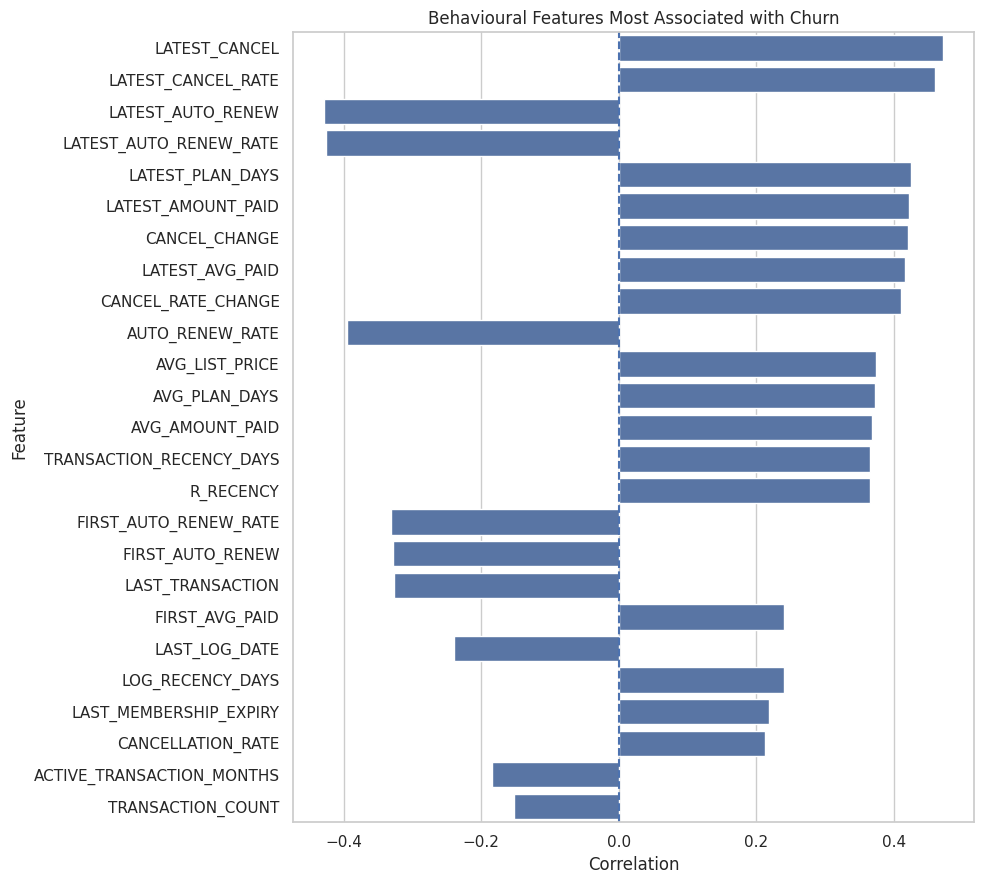

In [ ]:
top_corr = correlation_df.head(25)

plt.figure(figsize=(10,9))
sns.barplot(data=top_corr, x="Correlation", y="Feature")
plt.axvline(0, linestyle="--")
plt.title("Behavioural Features Most Associated with Churn")
plt.tight_layout()
plt.show()

## Part 54: RFM Correlation Specifically

In [ ]:
rfm_features = ["R_RECENCY", "F_FREQUENCY", "M_MONETARY"]

In [ ]:
rfm_churn = customer_tx.groupby("is_churn")[rfm_features].median().T
rfm_churn.columns = ["Retained", "Churned"]
display(rfm_churn)

,Retained,Churned
R_RECENCY,13.0,26.0
F_FREQUENCY,18.0,10.0
M_MONETARY,2035.0,2086.0


## Part 55: Interaction: Recency x Frequency

In [ ]:
customer_tx["R_GROUP"] = pd.qcut(customer_tx["R_RECENCY"], q=4, duplicates="drop")
customer_tx["F_GROUP"] = pd.qcut(customer_tx["F_FREQUENCY"], q=4, duplicates="drop")

In [ ]:
rf_interaction = customer_tx.groupby(["R_GROUP", "F_GROUP"], observed=False)["is_churn"].mean().unstack()

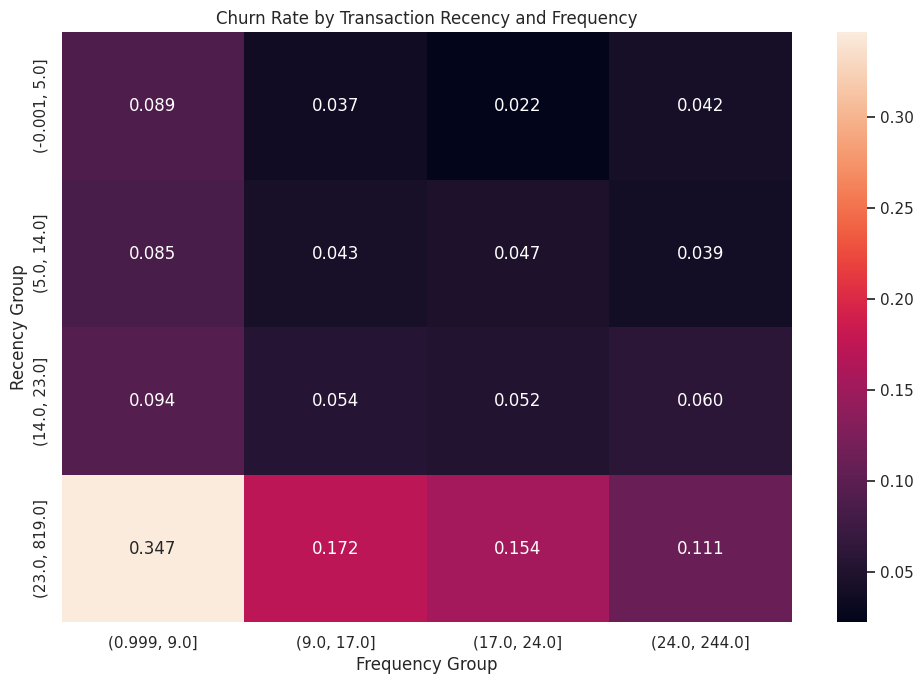

In [ ]:
plt.figure(figsize=(10,7))
sns.heatmap(rf_interaction, annot=True, fmt=".3f")
plt.title("Churn Rate by Transaction Recency and Frequency")
plt.xlabel("Frequency Group")
plt.ylabel("Recency Group")
plt.tight_layout()
plt.show()

## Part 56: Interaction: Cancellation x Auto-Renew

In [ ]:
customer_tx["CANCEL_GROUP"] = pd.qcut(customer_tx["CANCELLATION_RATE"], q=4, duplicates="drop")

In [ ]:
auto_cancel_interaction = customer_tx.groupby(["CANCEL_GROUP", "LATEST_AUTO_RENEW"], observed=False)["is_churn"].mean().unstack()

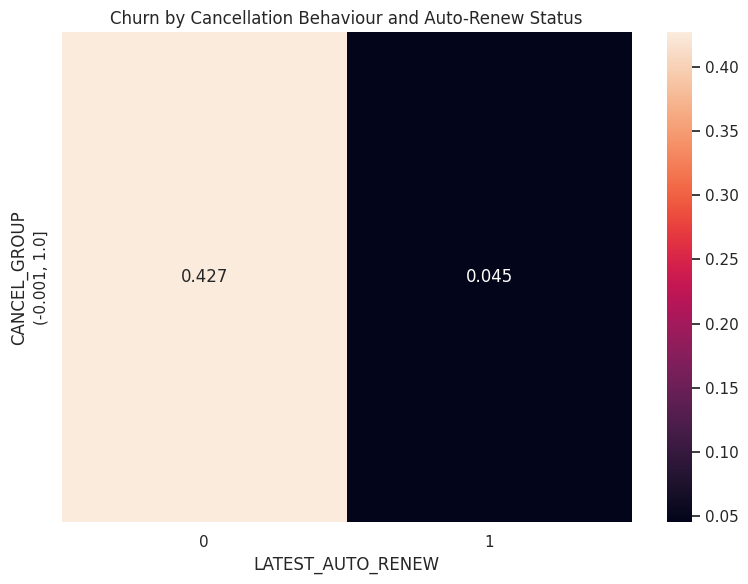

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(auto_cancel_interaction, annot=True, fmt=".3f")
plt.title("Churn by Cancellation Behaviour and Auto-Renew Status")
plt.tight_layout()
plt.show()

## Part 57: Save Aggregated Datasets

In [ ]:
transaction_features.to_pickle(BASE_PATH / "kkbox_transaction_features.pkl")
monthly_transactions.to_pickle(BASE_PATH / "kkbox_monthly_transactions.pkl")
trajectory.to_pickle(BASE_PATH / "kkbox_trajectory_features.pkl")
log_features.to_pickle(BASE_PATH / "kkbox_log_features.pkl")
customer_eda.to_pickle(BASE_PATH / "kkbox_customer_eda.pkl")

print("All aggregated EDA datasets saved!")

All aggregated EDA datasets saved!


## Part 58: Save Summary Tables

In [ ]:
churn_summary.to_csv(BASE_PATH / "kkbox_churn_summary.csv", index=False)
behaviour_summary.to_csv(BASE_PATH / "kkbox_transaction_behaviour_by_churn.csv")
trajectory_summary.to_csv(BASE_PATH / "kkbox_trajectory_by_churn.csv")
engagement_summary.to_csv(BASE_PATH / "kkbox_engagement_by_churn.csv")
correlation_df.to_csv(BASE_PATH / "kkbox_feature_correlations.csv", index=False)

print("EDA summary outputs saved.")

EDA summary outputs saved.


In [ ]:
print("\nEDA Complete!")
print("="*60)


EDA Complete!
